In [ ]:
!pip install -q transformers datasets tokenizers sentencepiece accelerate scikit-learn seaborn matplotlib


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import random

from datasets import load_dataset, Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from torch.optim import AdamW   # ✅ CORRECT IMPORT
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support
)
from sklearn.utils.class_weight import compute_class_weight


In [ ]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


In [ ]:
print("Downloading Dataset...")
try:
    dataset_raw = load_dataset("tamilmixsentiment")
    df = pd.DataFrame(dataset_raw["train"])
except Exception:
    url = "https://raw.githubusercontent.com/bharathichezhiyan/TamilMixSentiment/master/tamilmixsentiment_train.csv"
    df = pd.read_csv(url, sep="\t", names=["label", "text"])

print("Samples:", len(df))


Samples: 11335


In [ ]:
label_map = {
    'positive': 0, 'pos': 0, '0': 0, 0: 0,
    'negative': 1, 'neg': 1, '1': 1, 1: 1,
    'mixed_feelings': 2, 'mixed': 2, '2': 2, 2: 2,
    'unknown_state': 3, 'unknown': 3, '3': 3, 3: 3,
    'not-tamil': 4, 'not tamil': 4, '4': 4, 4: 4
}

def clean_label(val):
    s = str(val).strip().lower()
    return label_map.get(s, label_map.get(val, 3))

df["label"] = df["label"].apply(clean_label)
df = df.dropna(subset=["text", "label"])
df["text"] = df["text"].astype(str)

print(df["label"].value_counts())


label
0    7627
1    1448
2    1283
3     609
4     368
Name: count, dtype: int64


In [ ]:
def simple_augment(text):
    words = text.split()
    if len(words) > 3:
        i, j = random.sample(range(len(words)), 2)
        words[i], words[j] = words[j], words[i]
    return " ".join(words)

label_counts = df["label"].value_counts()
target_size = label_counts.max()

balanced = []

for label, count in label_counts.items():
    df_class = df[df["label"] == label]
    if count < target_size:
        extra = df_class.sample(target_size - count, replace=True, random_state=SEED)
        extra["text"] = extra["text"].apply(simple_augment)
        balanced.append(pd.concat([df_class, extra]))
    else:
        balanced.append(df_class)

df_balanced = pd.concat(balanced).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Balanced distribution:")
print(df_balanced["label"].value_counts())


Balanced distribution:
label
1    7627
2    7627
0    7627
4    7627
3    7627
Name: count, dtype: int64


In [ ]:
MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

ds = Dataset.from_pandas(df_balanced)

split1 = ds.train_test_split(test_size=0.2, seed=SEED)
split2 = split1["test"].train_test_split(test_size=0.5, seed=SEED)

dataset_dict = DatasetDict({
    "train": split1["train"],
    "validation": split2["train"],
    "test": split2["test"]
})


In [ ]:
def preprocess(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_ds = dataset_dict.map(preprocess, batched=True)
tokenized_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

print("✓ Tokenization complete")


Map:   0%|          | 0/30508 [00:00<?, ? examples/s]

Map:   0%|          | 0/3813 [00:00<?, ? examples/s]

Map:   0%|          | 0/3814 [00:00<?, ? examples/s]

✓ Tokenization complete


In [ ]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(df["label"]),
    y=df["label"]
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)


In [ ]:
def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return {
        "accuracy": accuracy_score(p.label_ids, preds),
        "f1": f1_score(p.label_ids, preds, average="macro")
    }

class WeightedTrainer(Trainer):
    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None  # ← REQUIRED
    ):
        labels = inputs["labels"]
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fn = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=5
).to(device)

optimizer = AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
args = TrainingArguments(
    output_dir="./roberta_adamw",
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none"
)


In [ ]:
trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    compute_metrics=compute_metrics,
    optimizers=(optimizer, None)
)

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.625800,0.435464,0.582481,0.489564
2,0.346800,0.256664,0.698400,0.629187
3,0.219700,0.159057,0.777078,0.715497
4,0.141500,0.116635,0.826646,0.788201
5,0.108400,0.099800,0.848938,0.821851


TrainOutput(global_step=9535, training_loss=0.3327113320581189, metrics={'train_runtime': 4934.6699, 'train_samples_per_second': 30.912, 'train_steps_per_second': 1.932, 'total_flos': 1.003401036286464e+16, 'train_loss': 0.3327113320581189, 'epoch': 5.0})

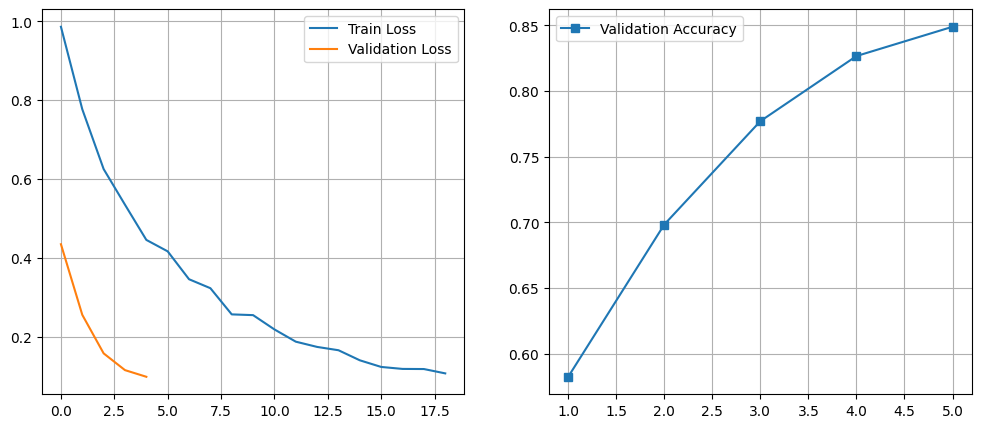

In [ ]:
history = trainer.state.log_history

train_loss = [x["loss"] for x in history if "loss" in x]
val_loss = [x["eval_loss"] for x in history if "eval_loss" in x]
val_acc = [x["eval_accuracy"] for x in history if "eval_accuracy" in x]

epochs = range(1, len(val_loss)+1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")
plt.legend(); plt.grid()

plt.subplot(1,2,2)
plt.plot(epochs, val_acc, marker="s", label="Validation Accuracy")
plt.legend(); plt.grid()

plt.show()


In [ ]:
pred = trainer.predict(tokenized_ds["test"])
y_true = pred.label_ids
y_pred = np.argmax(pred.predictions, axis=1)

class_names = ["Positive", "Negative", "Mixed", "Unknown", "Not-Tamil"]

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


              precision    recall  f1-score   support

    Positive     0.8524    0.3012    0.4451       767
    Negative     0.8018    0.9203    0.8570       778
       Mixed     0.6894    0.9582    0.8019       790
     Unknown     0.9260    1.0000    0.9616       726
   Not-Tamil     0.9805    1.0000    0.9901       753

    accuracy                         0.8346      3814
   macro avg     0.8500    0.8359    0.8111      3814
weighted avg     0.8476    0.8346    0.8089      3814



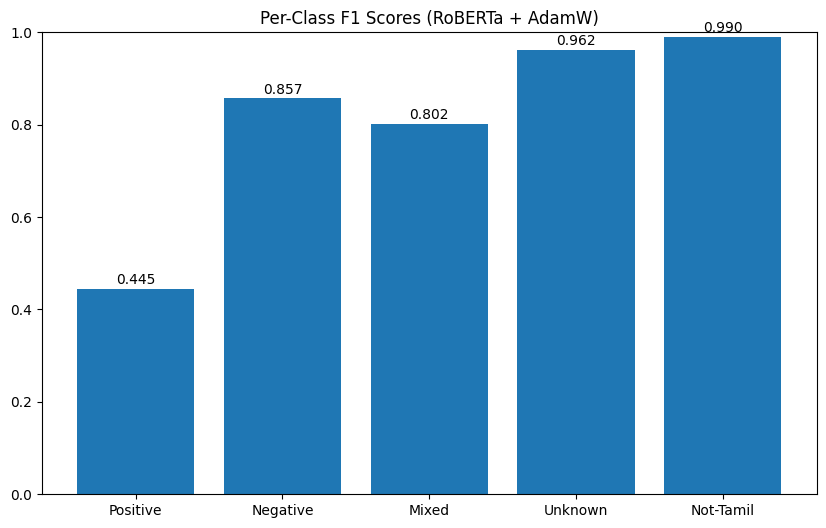

In [ ]:
_, _, f1_vals, _ = precision_recall_fscore_support(
    y_true, y_pred, labels=[0,1,2,3,4]
)

plt.figure(figsize=(10,6))
bars = plt.bar(class_names, f1_vals)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h+0.01, f"{h:.3f}", ha="center")

plt.ylim(0,1)
plt.title("Per-Class F1 Scores (RoBERTa + AdamW)")
plt.show()


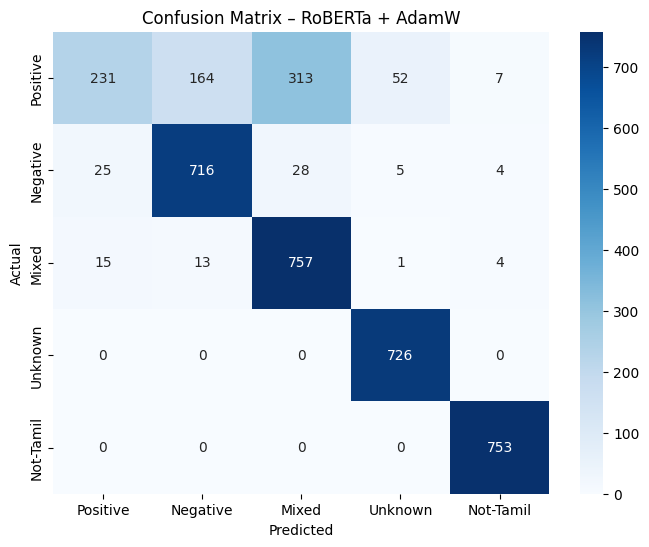

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – RoBERTa + AdamW")
plt.show()
